# PCA for Compression, Randomized PCA, Incremental PCA, Random Projection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.decomposition import IncrementalPCA
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection, SparseRandomProjection

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
mnist = fetch_openml('mnist_784', as_frame= False, parser = "auto")
X_train  , y_train = mnist.data[:60_000], mnist.target[60_000:]
X_test  , y_test = mnist.data[:60_000], mnist.target[60_000:]

## PCA for Compression

In [4]:
pca = PCA(0.95)
X_reduced = pca.fit_transform(X_train, y_train)

In [5]:
X_recovered = pca.inverse_transform(X_reduced)

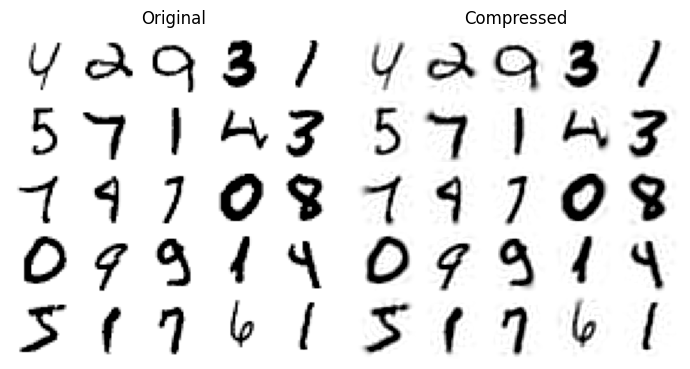

In [6]:
plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap = "binary",
                      vmin = 0, vmax = 225, extent = (row, row+1, col, col+1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")
            
save_fig("mnist_compression_plot")

## Randomized PCA

In [7]:
rnd_pca = PCA(n_components= 154, svd_solver= "randomized", random_state = 42)
X_reduced = rnd_pca.fit_transform(X_train)

## Incremnetal PCA

In [10]:
n_batches = 100
inc_pca = IncrementalPCA(n_components =  154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

#### Using NumPy's `memmap` class – a memory-map to an array stored in a binary file on disk.

Let's create the `memmap` instance, copy the MNIST training set into it, and call `flush()` which ensures that any data still in cache is saved to disk. This would typically be done by a first program:

In [11]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape = X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

In [12]:
X_mmap = np.memmap(filename, dtype = "float32", mode ="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

## Random Projection

In [13]:
m, eps = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=eps)
d

7300

In [14]:
d = int(4 * np.log(m) / (eps ** 2 / 2 - eps ** 3/ 3 ))
d

7300

In [15]:
n = 20_000
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d) # std dev = square root of variance

X = np.random.randn(m, n)
X_reduced = X @ P.T

In [16]:
gaussian_rnd_proj = GaussianRandomProjection(eps = eps, random_state = 42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

In [17]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

In [18]:
print("GaussianRmndomProjection fit")
%timeit GaussianRandomProjection(random_state = 42).fit(X)

print("SparseRandomProjectionfit ")
%timeit SparseRandomProjection(random_state = 42).fit(X)

gaussian_rnd_proj = GaussianRandomProjection(random_state = 42).fit(X)
sparse_rnd_proj = SparseRandomProjection(random_state=42).fit(X)

print("GaussianRmndomProjection fit ")
%timeit gaussian_rnd_proj.fit_transform(X)

print("SparseRandomProjectionfit ")
%timeit sparse_rnd_proj.fit_transform(X)

GaussianRmndomProjection fit
6.1 s ± 593 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjectionfit 
5.83 s ± 236 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
GaussianRmndomProjection fit 
18.6 s ± 122 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjectionfit 
12.5 s ± 3.25 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
